In [1]:
import os
import glob

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi

import src.util.open_meteo_api as meteo
import src.data.dataprep as prep

building = 0
price = "Realistic"

In [2]:
# Import the base data and resample it from 5 minutes to hourly
nl_data = prep.dutch_data('../data/Dutchdata_clean/building_' + str(building) + '.parquet', 'h', price=price)

In [3]:
# Old code to get the weather data from meteo, now just saved in a location for consistency

lat = 52.090
long = 5.088

weather = meteo.Open_meteo(lat, long, nl_data.index[0].strftime('%Y-%m-%d'), nl_data.index[-1].strftime('%Y-%m-%d'))
weather_data = weather.get_open_meteo_hourly()
weather_data.index = weather_data['date']
weather_data.index = weather_data.index.tz_localize(None)

Coordinates 52.056236267089844°N 5.128676414489746°E
Elevation 0.0 m asl
Timezone None None
Timezone difference to GMT+0 0 s


In [4]:
DHI_fcst_array = np.load('../../data/DHI_fcsts/DHI_fcst.npy')
DHI_fcst_array_noon = np.load('../../data/DHI_fcsts/DHI_fcst_noon.npy')

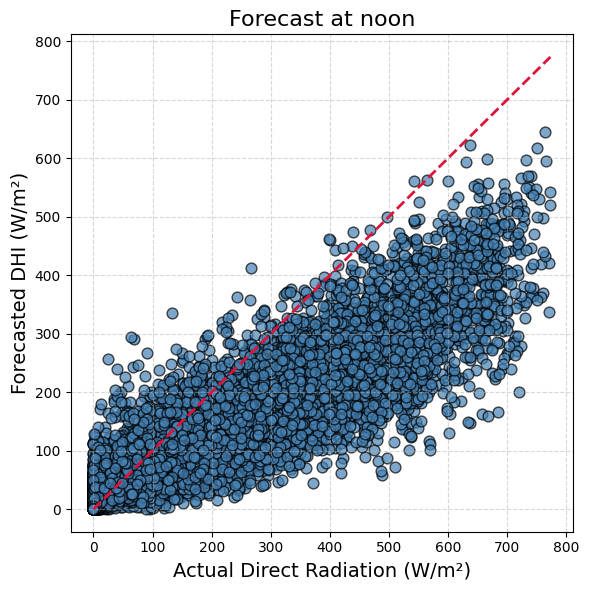

In [5]:
x = weather_data['direct_radiation']
y = DHI_fcst_array

# Set up the plot
plt.figure(figsize=(6, 6))
plt.scatter(x, y, 
            c='steelblue', edgecolor='k', alpha=0.7, s=60, label='Forecast vs Actual')

# Add x=y line
min_val = min(x.min(), y.min())
max_val = max(x.max(), y.max())
plt.plot([min_val, max_val], [min_val, max_val], 
         color='crimson', linestyle='--', linewidth=2)

# Labels and title
plt.title('Forecast at noon', fontsize=16)
plt.xlabel('Actual Direct Radiation (W/m²)', fontsize=14)
plt.ylabel('Forecasted DHI (W/m²)', fontsize=14)

# Grid and legend
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [6]:
from sklearn.metrics import mean_squared_error as mse

In [7]:
mse(x, y, squared=False) / max(x)

0.09856121022557895

In [15]:
load_fcst_array = np.load('../../data/load_fcsts/building_0_0.5_noise_forecast.npy')

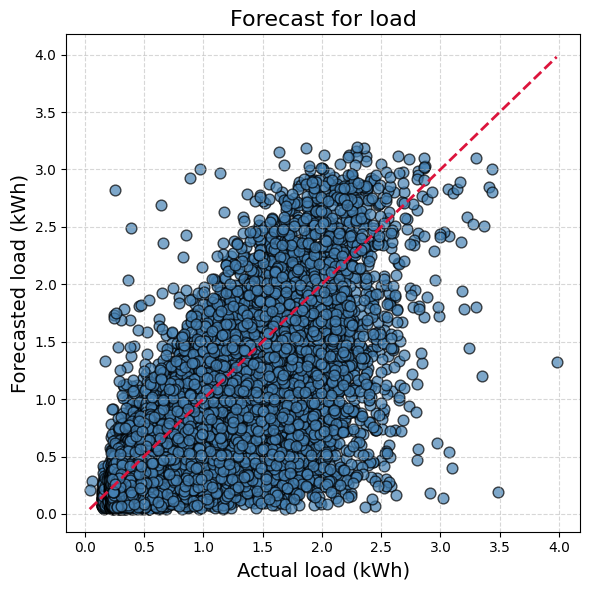

In [16]:
x = nl_data['load']
y = load_fcst_array

# Set up the plot
plt.figure(figsize=(6, 6))
plt.scatter(x, y, 
            c='steelblue', edgecolor='k', alpha=0.7, s=60, label='Forecast vs Actual')

# Add x=y line
min_val = min(x.min(), y.min())
max_val = max(x.max(), y.max())
plt.plot([min_val, max_val], [min_val, max_val], 
         color='crimson', linestyle='--', linewidth=2)

# Labels and title
plt.title('Forecast for load', fontsize=16)
plt.xlabel('Actual load (kWh)', fontsize=14)
plt.ylabel('Forecasted load (kWh)', fontsize=14)

# Grid and legend
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [17]:
mse(x,y,squared=False) / max(x)

0.09837958918982949

In [18]:
from sklearn.metrics import mean_absolute_percentage_error as mape

In [19]:
mape(x,y)

0.3330538433290241

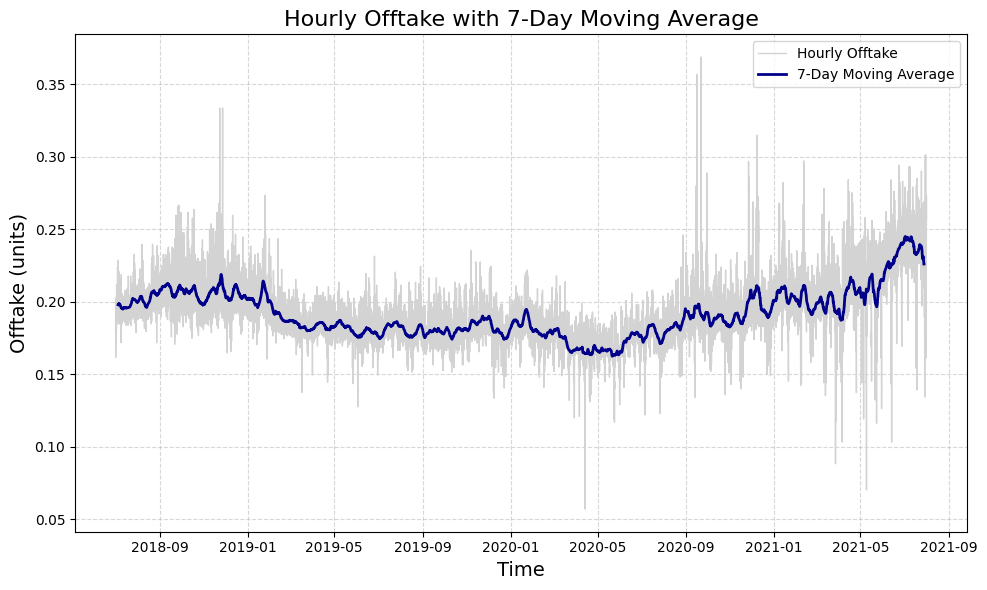

In [31]:
# Compute 7-day (168-hour) moving average
weekly_ma = nl_data['offtake'].rolling(window=24*7, center=True).mean()

# Set up the plot
plt.figure(figsize=(10, 6))
plt.plot(nl_data['offtake'], color='lightgray', linewidth=1, label='Hourly Offtake')
plt.plot(weekly_ma, color='darkblue', linewidth=2, label='7-Day Moving Average')

# Add labels and title
plt.title('Hourly Offtake with 7-Day Moving Average', fontsize=16)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Offtake (units)', fontsize=14)

# Formatting
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
self = self
batches = batches
_rescale = rescale
torch = torch

for input, output in batches:
    pv_train, y_train = self.model(input[:, :, 0:self.model.input_size],
                                   input[:, -self.T:, -4],
                                   input[:, -self.T:, -3],
                                   input[:, -self.T:, -2],
                                   input[:, -1, -1])

    y_train = self.cvx(_rescale(output[:, :, 0], self.scaler),
                       input[:, -self.T:, -5],  # CHANGED from 4 to 5: we use the REAL load at inference
                       input[:, -self.T:, -3],
                       input[:, -self.T:, -2],
                       input[:, -1, -1],
                       y_train[-2],
                       y_train[-1])

    prediction = (torch.bmm(y_train[0].unsqueeze(1), input[:, -self.T:, -3].unsqueeze(-1)) -
                  torch.bmm(y_train[1].unsqueeze(1), input[:, -self.T:, -2].unsqueeze(-1)))
    prediction = prediction.squeeze([1, 2])

    mse_loss = self.criterion(pv_train, output[:, :, 0])
    regret = self.criterion(prediction, output[:, -1, 1])


In [15]:
buildings = []

folder_path = os.path.abspath(os.path.join(os.getcwd(), '../results/'))
file_paths = glob.glob(os.path.join(folder_path, '*'))
files = [os.path.basename(file_path) for file_path in file_paths]

In [16]:
dataframes = {}

# Loop through each file and read into a DataFrame
for file in files:  # Assuming filenames are building_0.csv to building_15.csv
    # Read the CSV
    df = pd.read_csv('../results/' + file, index_col=0)
    file_name = file.rstrip('.csv')
    # Store only the columns 'real' and 'rmse'
    dataframes[file_name] = df[['Cost', 'MSE']]

In [17]:
# Combine all DataFrames into a single DataFrame with MultiIndex
combined_df = pd.concat(dataframes, axis=0)

In [49]:
combined_df.index[-1]

('building_9_metri', 'PERFECT')

In [51]:
# Define the models to filter
selected_models = ["PERFECT", "CVX", "LSTM-CVX", "LSTM", "NAIVE"]

# Select only the relevant models
filtered_df = combined_df.loc[(slice(None), selected_models), :]

# Compute the average Cost per Model
avg_cost_per_model = filtered_df.groupby("Model")["Cost"].mean()

# Compute the average RMSE per Model
avg_rmse_per_model = filtered_df.groupby("Model")["MSE"].apply(lambda x: np.sqrt(x).mean())

# Display results
print("Average Cost per Model:\n", avg_cost_per_model)
print("\nAverage RMSE per Model:\n", avg_rmse_per_model)

Average Cost per Model:
 Model
CVX         294.089756
LSTM        307.614807
LSTM-CVX    288.975874
NAIVE       343.203993
PERFECT      84.551779
Name: Cost, dtype: float64

Average RMSE per Model:
 Model
CVX         0.154612
LSTM        0.111070
LSTM-CVX    0.142891
NAIVE       0.138757
PERFECT     0.000000
Name: MSE, dtype: float64


In [18]:
def reset_multiindex_building_indices(df):
    # Extract the unique building names from the first level of the MultiIndex
    unique_buildings = df.index.levels[0]
    
    # Create a mapping for the new sequential building names
    new_building_names = [f'building_{i}' for i in range(len(unique_buildings))]
    building_mapping = dict(zip(unique_buildings, new_building_names))
    
    # Replace the old building names with the new names in the MultiIndex
    new_index = df.index.map(lambda idx: (building_mapping[idx[0]], idx[1]))
    
    # Assign the updated index to the dataframe
    df.index = pd.MultiIndex.from_tuples(new_index, names=df.index.names)
    
    return df

In [19]:
from sklearn.preprocessing import MinMaxScaler
# Create a new DataFrame to store scaled values
scaled_data = combined_df.copy()

# Initialize a scaler for each building and apply it
scaler = MinMaxScaler()

for i in range(0,len(files)*6,6):
    # Filter rows for the current building
    current_building = combined_df[i:i+6].copy()
    
    # Apply MinMaxScaler to 'real' and 'rmse' separately
    mse_scaled = scaler.fit_transform(current_building[['MSE']])
    cost_scaled = scaler.fit_transform(current_building[['Cost']])
    
    # Update the scaled DataFrame
    scaled_data.loc[files[int(i/6)].rstrip('.csv'),'MSE'] = mse_scaled
    scaled_data.loc[files[int(i/6)].rstrip('.csv'),'Cost'] = cost_scaled

In [20]:
scaled_data.to_csv('../results/overall_results.csv')

In [21]:
scaled_data = reset_multiindex_building_indices(scaled_data)

In [22]:
# Step 1: Reshape the DataFrame
# Reset the multi-index for easier manipulation
reshaped_df = scaled_data.reset_index()

# Pivot the DataFrame to have 'building' as columns and 'real'/'rmse' as rows
radar_df = reshaped_df.pivot_table(index='Model', columns='level_0', values=['Cost', 'MSE'])

# Flatten the column index for easier access
radar_df.columns = ['_'.join(col).strip() for col in radar_df.columns.values]

# Step 2: Prepare the radar chart
categories = radar_df.columns[:len(files)].tolist()  # Buildings as variables
N = len(categories)

In [23]:
# Calculate angles for the radar chart
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # Close the circle

In [24]:
import re
from math import pi

def natural_sort_key(label):
    return [int(text) if text.isdigit() else text for text in re.split(r'(\d+)', label)]

def create_radar_plot(ax, title, data, angle_labels, group_labels, strip, ylim=(0, 1)):
    # Ensure angle_labels are sorted naturally
    sorted_labels = sorted(angle_labels, key=natural_sort_key)
    
    # Ensure the data is ordered according to the sorted angle_labels
    data = data[sorted_labels]
    
    categories_stripped = []
    for building in sorted_labels:
        name = building.lstrip(strip)
        categories_stripped.append(name)
    
    sorted_labels = sorted(categories_stripped, key=natural_sort_key)    
    
    # Calculate the angles for each label
    num_vars = len(sorted_labels)
    angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
    angles += angles[:1]  # Close the circle

    # Ensure the first axis is at the top
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    
    # Draw one axis per variable (building) + add labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(sorted_labels, color='grey', size=11)
    
    # Draw y-labels and set limits
    ax.set_rlabel_position(0)
    ax.set_yticks([0.25, 0.5, 0.75, 1])
    ax.set_yticklabels(["0.25", "0.5", "0.75", "1"], color="grey", size=14)
    ax.set_ylim(*ylim)
    
    for label in ax.get_yticklabels():
        label.set_verticalalignment('top')
    
    # Plot each group
    for group_label, color in zip(group_labels, ['b', 'r', 'g', 'p']):
        values = data.loc[group_label].tolist()
        values += values[:1]  # Close the circle
        ax.plot(angles, values, linewidth=1, linestyle='solid', label=group_label)
        ax.fill(angles, values, color, alpha=0.1)
    
    # Add legend and title
    ax.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1), fontsize=14)
    ax.set_title(title, size=15, color='blue', y=1.1)


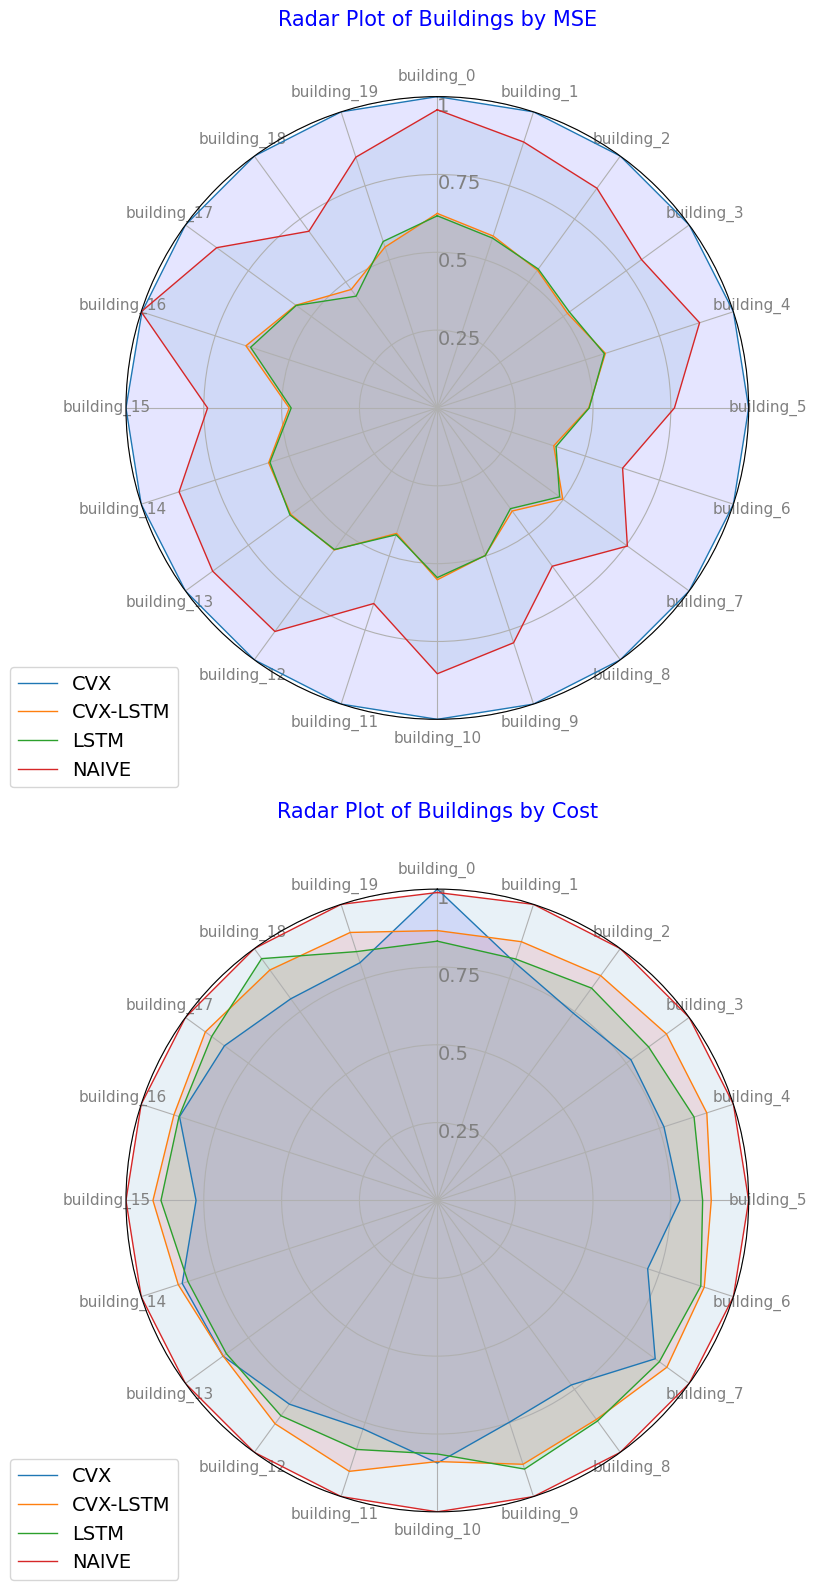

In [25]:
# Prepare figure and axes for two radar plots
fig, axs = plt.subplots(2, 1, figsize=(8, 16), subplot_kw=dict(polar=True))

# Radar Plot 1: RMSE
create_radar_plot(
    ax=axs[0],
    title="Radar Plot of Buildings by MSE",
    data=radar_df[radar_df.columns[len(files):]],  # Subset of RMSE data
    angle_labels=radar_df.columns[len(files):],
    group_labels=['CVX', 'CVX-LSTM', 'LSTM', 'NAIVE'],
    strip='MSE_'
)

# Radar Plot 2: Cost
create_radar_plot(
    ax=axs[1],
    title="Radar Plot of Buildings by Cost",
    data=radar_df[radar_df.columns[:len(files)]],  # Subset of Cost data
    angle_labels=radar_df.columns[:len(files)],
    group_labels=['CVX', 'CVX-LSTM', 'LSTM', 'NAIVE'],
    strip='Cost_'
)

# Adjust layout and display the plots
plt.tight_layout()
plt.show()

In [35]:
import matplotlib.pyplot as plt

# Assuming mse_data and cost_data are already defined
df = scaled_data.reset_index()  # Ensure the building names are a column
df.rename(columns={"level_0": "Building"}, inplace=True)  # Rename for clarity
df_filtered = df[~df["Model"].isin(["CVX-LSTM", "PERFECT"])]

# Extract building numbers instead of full names (e.g., "building_0" → "0")
df_filtered["Building"] = df_filtered["Building"].str.extract(r'(\d+)').astype(int)

# Sort buildings numerically
df_filtered = df_filtered.sort_values("Building")

# Get unique buildings and models
buildings = df_filtered["Building"].unique()
models = df_filtered["Model"].unique()

# Convert data to radar plot format
mse_data = {}
cost_data = {}

for model in models:
    mse_data[model] = df_filtered[df_filtered["Model"] == model].set_index("Building")["MSE"].reindex(buildings).fillna(0).values
    cost_data[model] = df_filtered[df_filtered["Model"] == model].set_index("Building")["Cost"].reindex(buildings).fillna(0).values




C:\Users\joris\AppData\Local\Temp\ipykernel_995276\930593253.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["Building"] = df_filtered["Building"].str.extract(r'(\d+)').astype(int)


In [38]:
def plot_scatter_plot(mse_data, cost_data):
    # Create a figure
    plt.figure(figsize=(10, 5), dpi=180)

    # Scatter plot for each model
    for model in mse_data.keys():
        # Get the MSE and cost values for each building
        mse_values = mse_data[model]
        cost_values = cost_data[model]

        # Scatter plot
        plt.scatter(mse_values, cost_values, label=model, alpha=0.7)

    # Set labels and title
    plt.xlabel("RMSE", fontsize=12)
    plt.ylabel("Cost", fontsize=12)
    plt.title("Scatter Plot of Cost vs. RMSE", fontsize=14, fontweight="bold")

    # Add a legend
    plt.legend(title="Models", loc="lower left", fontsize=10)

    # Show grid for better visibility
    plt.grid(True, linestyle="--", alpha=0.6)

    # Show the plot
    plt.tight_layout()
    plt.show()

In [39]:
mse_data['VOF'] =mse_data.pop('CVX')
mse_data['TVOF'] =mse_data.pop('LSTM-CVX')

In [40]:
cost_data['VOF'] =cost_data.pop('CVX')
cost_data['TVOF'] =cost_data.pop('LSTM-CVX')

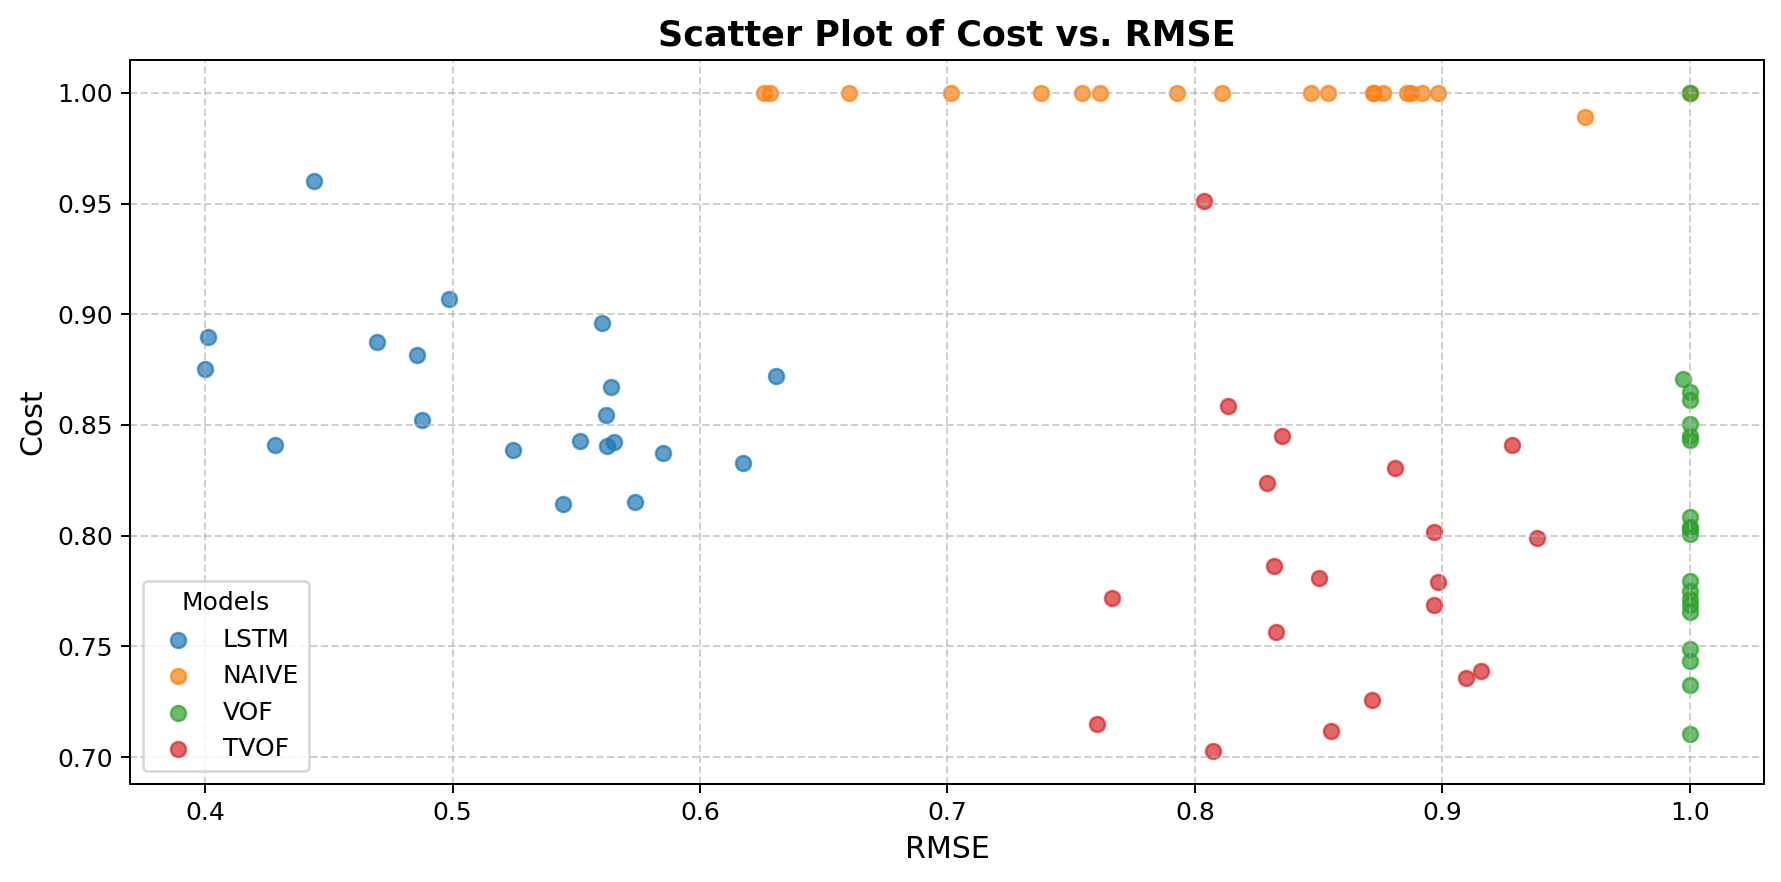

In [41]:
# Call the function to plot the scatter plot
plot_scatter_plot(mse_data, cost_data)

In [ ]:
# 1. Create hourly datetime index
datetime_index = pd.date_range("2020-05-08 00:00:00", "2021-07-31 23:00:00", freq="h")
n_hours = len(datetime_index)  # Should be 10,800

# 2. Setup
folder_path = "../results/optimisation/"
target_noise = "4"  # For noise = 0.1
pkl_files = [
    f for f in os.listdir(folder_path)
    if f.endswith(".pkl") and f"_{target_noise}_noise.pkl" in f
]

# 3. Load and transform
column_data = {}

for file in pkl_files:
    building_id = file.split("_")[3]
    file_path = os.path.join(folder_path, file)

    with open(file_path, "rb") as f:
        building_dict = pickle.load(f)

    for dict_key, var_dict in building_dict.items():
        for var_key, array in var_dict.items():
            arr = np.asarray(array)

            # Special handling for 'energy' with shape (450, 25)
            if var_key == 'energy' and arr.shape[1] == 25:
                arr = arr[:, :24]

            # Ensure shape is (450, 24)
            if arr.shape != (450, 24):
                raise ValueError(f"Unexpected shape {arr.shape} in {file} for {dict_key}/{var_key}")

            # Flatten to (450*24,) = (10800,)
            flat_array = arr.flatten()

            if flat_array.shape[0] != n_hours:
                raise ValueError(f"Length mismatch after flattening {file} {dict_key}/{var_key}")

            col_key = (f"building_{building_id}", dict_key, var_key)
            column_data[col_key] = flat_array

# 4. Build final DataFrame
df_final = pd.DataFrame(column_data, index=datetime_index)
df_final.columns = pd.MultiIndex.from_tuples(df_final.columns, names=["building", "dictionary", "variable"])
df_final = df_final.sort_index(axis=1)

# Loop over all unique building and dictionary combinations
for building in df_final.columns.levels[0]:
    for dictionary in df_final[building].columns.levels[0]:
        imp = df_final[building][dictionary]['imp']
        exp = df_final[building][dictionary]['exp']
        offtake = df_final[building][dictionary]['offtake']
        injection = df_final[building][dictionary]['injection']

        # Compute cost
        cost = imp * offtake - exp * injection

        # Assign to new MultiIndex column
        df_final[(building, dictionary, 'cost')] = cost

# 1. Flatten the MultiIndex columns
df_flat = df_final.copy()
df_flat.columns = ['|'.join(col).strip() for col in df_flat.columns.values]

# 2. Reset index to turn the datetime index into a column
df_flat = df_flat.reset_index()

# 3. Melt the flattened columns
df_long = df_flat.melt(
    id_vars='index',
    var_name='combined',
    value_name='value'
).rename(columns={'index': 'datetime'})

# 4. Split 'combined' back into building, dictionary, variable
df_long[['building', 'dictionary', 'variable']] = df_long['combined'].str.split('|', expand=True)

# 5. Drop the combined column
df_long = df_long.drop(columns='combined')

# Optional: sort the result
df_long = df_long.sort_values(['datetime', 'building', 'dictionary', 'variable']).reset_index(drop=True)
df_long.to_pickle("../results/all_data_long_" + str(target_noise) + "_noise.pkl")